# 🌎 Módulo 2 — Análise Espacial Aplicada ao Monitoramento do Crédito Rural
## Bloco 1: Estimativa de Densidade de Kernel (KDE) e I de Moran Global

### O que vamos aprender neste bloco?

Neste primeiro bloco, vamos trabalhar com uma pergunta que aparece naturalmente
quando olhamos para os dados de Comunicações de Perda (COPs) do Proagro:

> **"Onde se concentram os sinistros de soja no Brasil?  
>   Essa concentração é fruto do acaso ou existe um padrão espacial real?"**

Para responder, vamos aprender duas técnicas:

| Técnica | Pergunta que responde | Tipo de dado |
|---------|----------------------|-------------|
| **KDE** (Kernel Density Estimation) | *Onde os sinistros se concentram?* | Pontos (coordenadas das glebas) |
| **I de Moran Global** | *Existe padrão espacial ou é aleatório?* | Valores agregados por município |

### Dados utilizados
- `sicor-interest-data.csv` — COPs de soja georreferenciadas ()
- Shapefile de municípios IBGE 2024 ()

> ⚠️ **Este material é exclusivamente didático.** As análises servem para ensinar
> conceitos e técnicas — não para emitir juízos sobre casos reais.

---
# Parte 1 — Carregamento e Exploração dos Dados

Antes de qualquer análise, precisamos carregar e entender os dados que vamos usar.
Nesta parte vamos:
1. Instalar as bibliotecas necessárias
2. Ler o arquivo de COPs do Sicor
3. Explorar visualmente a distribuição dos sinistros

## 1.1 Instalação de Bibliotecas

A célula abaixo instala as bibliotecas que usaremos **neste bloco**.
No Google Colab, a maioria já vem instalada; as que faltam serão instaladas agora.

In [1]:
# Instalação das bibliotecas necessárias para o Bloco 1
# (executar esta célula apenas uma vez por sessão do Colab)
!pip install geopandas cartopy libpysal esda splot mapclassify -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 97.3 MB/s eta 0:00:00


## 1.2 Leitura do arquivo de COPs do Sicor

O arquivo `sicor-interest-data.csv` contém as Comunicações de Perda (COPs) **deferidas**

Cada linha é uma COP — isto é, uma comunicação feita pelo produtor informando que
houve perda na lavoura por algum fenômeno adverso (seca, chuva excessiva, granizo, etc.).

Cada COP tem, entre outras informações:
- As **coordenadas geográficas** do centroide da gleba (longitude e latitude)
- O **fenômeno adverso** comunicado (ex.: Seca, Chuva excessiva)
- As **datas** de plantio, colheita e do evento
- A **área** da gleba em hectares
- O **município** (código IBGE)

In [2]:
# monta o meu drive aqui no colab/máquina virtual
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/MaterialGeotec/basededados/

/content/drive/MyDrive/MaterialGeotec/basededados


In [4]:
# Importamos o pandas para ler o CSV
import pandas as pd

# Leitura do CSV
df = pd.read_csv('sicor-interest-data.csv')

# Quantas linhas temos?
print(f"Total de registros carregados: {len(df)}")

Total de registros carregados: 1506629


### Ajuste de tipos de dados

Algumas colunas chegam como texto mas precisamos que sejam números (latitude, longitude, área)
ou datas. Vamos converter uma a uma.

In [5]:
import pandas as pd

df = df.rename(columns={'latitude_centroide':'latitude', 'longitude_centroide':'longitude'})

# Converter latitude e longitude para números
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')

# Converter área para número
df['area_gleba_ha'] = pd.to_numeric(df['area_gleba_ha'], errors='coerce')

# Converter ano para número inteiro
df['ano_emissao'] = pd.to_numeric(df['ano_emissao'], errors='coerce')

# Converter colunas de datas
colunas_datas = [
    'dt_inicio_evento', 'dt_fim_evento', 'dt_comunicacao',
    'dt_inicio_plantio', 'dt_fim_plantio',
    'dt_inicio_colheita', 'dt_fim_colheita',
]
for col in colunas_datas:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Tipos de dados após conversão:")
print(df[['longitude', 'latitude', 'area_gleba_ha', 'ano_emissao', 'dt_inicio_evento']].dtypes)

Tipos de dados após conversão:
longitude                  float64
latitude                   float64
area_gleba_ha              float64
ano_emissao                  int64
dt_inicio_evento    datetime64[ns]
dtype: object


### Remoção de registros sem coordenadas & ajuste nas coordenadas

Para as análises espaciais, precisamos que todas as linhas tenham latitude e longitude
válidas. Vamos remover as que não têm.

In [6]:
import pandas as pd

# Contar quantos registros não têm coordenadas
sem_lon = df['longitude'].isna().sum()
sem_lat = df['latitude'].isna().sum()
print(f"Registros sem longitude: {sem_lon}")
print(f"Registros sem latitude:  {sem_lat}")

# Remover esses registros
df = df.dropna(subset=['longitude', 'latitude'])
print(f"\nRegistros restantes após limpeza: {len(df)}")

Registros sem longitude: 192025
Registros sem latitude:  192025

Registros restantes após limpeza: 1314604


In [7]:
# aqui fazemos o ajuste nas coordenadas para garantir que são no BR
df['longitude'] = df['longitude'].abs()*-1
df = df.loc[df['latitude'][(df['latitude'] >= -34) & (df['latitude'] <= 6)].index]
df = df.loc[df['longitude'][(df['longitude'] >= -75) & (df['longitude'] <= -33)].index]


In [8]:
# Aqui vamos simplificar nossas coordenadas para não pesar muito nas análises
df[['longitude', 'latitude']] = df[['longitude', 'latitude']].round(2).drop_duplicates()

## 1.3 Exploração inicial dos dados

Antes de aplicar qualquer técnica estatística, vale a pena **olhar** os dados.
Vamos responder algumas perguntas básicas:
- Quantos sinistros por fenômeno adverso?
- Quantos por estado?
- Quantos por safra?

In [9]:
import pandas as pd

# Quantos sinistros por fenômeno adverso?
print("=== Sinistros por fenômeno adverso ===")
contagem_evento = df['nome_evento'].value_counts()
print(contagem_evento)
print()

# Quantos por estado?
print("=== Sinistros por estado ===")
contagem_estado = df['cd_estado'].value_counts()
print(contagem_estado)
print()

# Quantos por ano-safra?
print("=== Sinistros por ano-safra ===")
contagem_ano = df['ano_emissao'].value_counts().sort_index()
print(contagem_ano)

=== Sinistros por fenômeno adverso ===
nome_evento
Seca                                   754794
Chuva excessiva                        297265
Geada                                  108731
Doença ou praga                         43611
Variação excessiva de temperatura       38711
Vento forte                             32314
Granizo                                 31374
Vendaval                                 3259
Chuva na colheita                        2082
Vento frio                                762
Tromba de água                            372
Outros fenômenos naturais fortuitos       221
Enchentes                                 216
Raio                                       22
Name: count, dtype: int64

=== Sinistros por estado ===
cd_estado
RS    731655
PR    430132
SC    115872
SE     12812
BA     11517
MS      5605
ES      1892
MG      1247
SP      1241
AL       904
RJ       234
GO       180
MT       123
TO       101
MA        68
PE        42
CE        35
RN        35
PI   

### Gráfico de barras — Sinistros por fenômeno

Um gráfico simples nos dá uma visão rápida de quais fenômenos causam mais perdas.

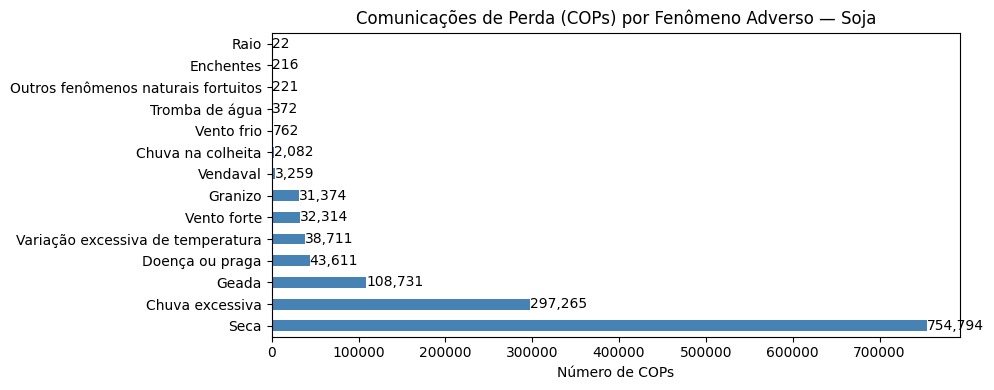

In [10]:
import matplotlib.pyplot as plt

# Contagem por fenômeno adverso
contagem_evento = df['nome_evento'].value_counts()

# Gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(10, 4))
contagem_evento.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Número de COPs')
ax.set_ylabel('')
ax.set_title('Comunicações de Perda (COPs) por Fenômeno Adverso — Soja')

# Adiciona os números ao lado de cada barra
for i, v in enumerate(contagem_evento.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 1.4 Primeiro mapa: onde estão as COPs?

Agora vamos colocar os pontos no mapa. Cada ponto é uma COP — uma gleba onde o
produtor comunicou perda.

Para isso vamos usar o **GeoDataFrame** do geopandas. Ele funciona como uma tabela
normal do pandas, mas com uma coluna especial chamada `geometry` que guarda a
posição geográfica de cada linha (neste caso, pontos).

In [11]:
import geopandas as gpd
from shapely.geometry import Point

# Criar uma lista de pontos a partir de longitude e latitude
# Cada ponto representa a posição da gleba no mapa
geometrias = []
for lon, lat in zip(df['longitude'], df['latitude']):
    ponto = Point(lon, lat)
    geometrias.append(ponto)

# Criar o GeoDataFrame
# EPSG:4674 = SIRGAS 2000, o sistema de coordenadas oficial do Brasil
gdf = gpd.GeoDataFrame(df, geometry=geometrias, crs='EPSG:4674')

print(f"GeoDataFrame criado com {len(gdf)} pontos")
print(f"Sistema de coordenadas: {gdf.crs}")
gdf[['ref_bacen', 'nome_evento', 'longitude', 'latitude', 'geometry']].head()

GeoDataFrame criado com 1313734 pontos
Sistema de coordenadas: EPSG:4674


,ref_bacen,nome_evento,longitude,latitude,geometry
0,516578816,Chuva excessiva,-52.45,-27.64,POINT (-52.45 -27.64)
11,509939195,Seca,-55.26,-27.94,POINT (-55.26 -27.94)
12,512442149,Seca,-52.96,-29.20,POINT (-52.96 -29.2)
14,514182145,Seca,-52.19,-28.24,POINT (-52.19 -28.24)
15,513532353,Chuva excessiva,-52.51,-27.74,POINT (-52.51 -27.74)


### Mapa simples com todos os pontos

Vamos plotar todos os pontos de uma vez. Cada cor representa um fenômeno adverso diferente.

> 💡 **Dica:** Observe como os pontos de "Seca" e "Chuva excessiva" se distribuem
> de forma diferente no espaço. Isso já nos dá uma intuição de que existe um
> **padrão espacial** — que é exatamente o que vamos investigar com KDE e Moran.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242

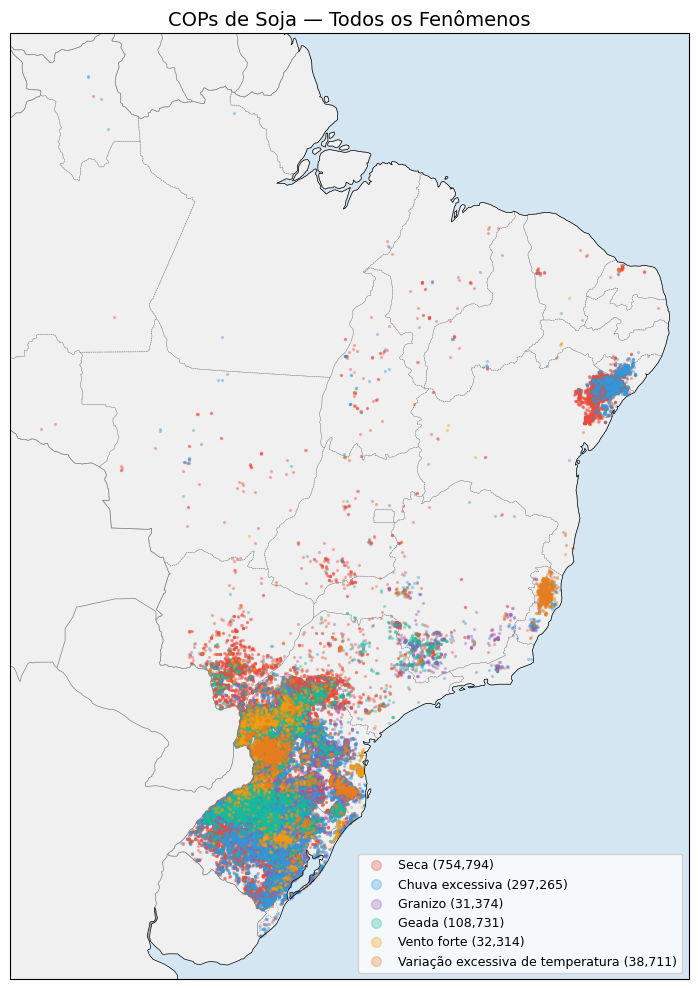

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Definimos as cores para cada fenômeno
cores = {
    'Seca':                                '#E74C3C',  # vermelho
    'Chuva excessiva':                     '#3498DB',  # azul
    'Granizo':                             '#9B59B6',  # roxo
    'Geada':                               '#1ABC9C',  # verde-água
    'Vento forte':                         '#F39C12',  # amarelo
    'Variação excessiva de temperatura':   '#E67E22',  # laranja
}

proj = ccrs.PlateCarree() # nossa projeção favorita → WGS84

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': proj})

# Plotar cada fenômeno separadamente (assim temos a legenda com as cores certas)
for evento, cor in cores.items():
    # Filtrar apenas as linhas deste fenômeno
    mascara = gdf['nome_evento'] == evento
    quantidade = mascara.sum()

    if quantidade > 0:
        gdf[mascara].plot(
            ax=ax,
            color=cor,
            markersize=2,
            alpha=0.3,
            label=f'{evento} ({quantidade:,})',
        )

ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('COPs de Soja — Todos os Fenômenos', fontsize=14)
ax.legend(loc='lower right', fontsize=9, markerscale=5)

plt.tight_layout()
plt.show()

> **🤔 Reflexão para o aluno:** Olhando o mapa acima, você consegue identificar regiões
> com mais sinistros? Parece haver "aglomerados" (clusters) ou os pontos estão
> espalhados de forma uniforme?
>
> Essa pergunta é o ponto de partida para as técnicas que vamos aprender a seguir.

---
# Parte 2 — Estimativa de Densidade de Kernel (KDE)

## 2.1 O problema: pontos demais, padrão de menos

Quando plotamos milhares de pontos no mapa (como fizemos acima), é difícil enxergar
**onde realmente estão as concentrações**. Os pontos se sobrepõem, e regiões com
10 COPs parecem iguais a regiões com 1.000 COPs.

Precisamos de uma forma de transformar esses **pontos discretos** em uma **superfície
contínua de densidade** — algo como um "mapa de calor" que mostra onde os eventos
se concentram mais.

É exatamente isso que o **KDE (Kernel Density Estimation)** faz.

## 2.2 O que é o KDE? — Uma analogia

Imagine que cada COP é uma **vela acesa** colocada no mapa, na posição exata da gleba.

Cada vela emite uma "luz" que se espalha ao redor — mais forte no centro, mais fraca
nas bordas. Essa "luz" é a **função kernel** (geralmente uma curva em forma de sino,
chamada gaussiana).

Agora imagine que você está olhando o mapa **de cima**. Onde tem muitas velas juntas,
a luz é intensa. Onde tem poucas velas, a luz é fraca.

O KDE faz exatamente isso: soma a "luz" de todos os pontos e gera uma superfície
contínua que mostra onde os eventos se concentram.

**Parâmetro-chave: o bandwidth (largura de banda)**  
É o "alcance" da luz de cada vela. Se o bandwidth é grande, a luz se espalha muito
e o mapa fica suavizado. Se é pequeno, a luz fica concentrada e o mapa mostra
detalhes locais.

> 💡 **No contexto Proagro:** O KDE nos ajuda a responder: "Em que regiões as
> comunicações de perda por seca (ou granizo, ou chuva excessiva) se concentram?"

## 2.3 KDE na prática — Densidade de COPs por Seca

Vamos aplicar o KDE nos pontos de COPs por **Seca**, que é o fenômeno mais frequente
nos nossos dados.

A ideia passo a passo:
1. Pegar as coordenadas (longitude, latitude) de todas as COPs por Seca
2. Criar uma grade regular de pontos sobre a área de estudo
3. Para cada ponto da grade, calcular a "densidade" de COPs ao redor
4. Plotar o resultado como um mapa de calor

### Passo 1: Filtrar apenas as COPs por Seca

In [13]:
import pandas as pd

# Filtrar apenas COPs por Seca
df_seca = df[df['nome_evento'] == 'Seca'].copy()

print(f"Total de COPs por Seca: {len(df_seca)}")
print(f"Período: {df_seca['ano_emissao'].min():.0f} a {df_seca['ano_emissao'].max():.0f}")
print(f"Longitude: de {df_seca['longitude'].min():.2f} a {df_seca['longitude'].max():.2f}")
print(f"Latitude:  de {df_seca['latitude'].min():.2f} a {df_seca['latitude'].max():.2f}")

Total de COPs por Seca: 754794
Período: 2015 a 2024
Longitude: de -63.38 a -35.35
Latitude:  de -33.68 a 2.15


### Passo 2: Extrair as coordenadas como arrays NumPy

O KDE trabalha com arrays numéricos (vetores de números), não com DataFrames.
Vamos extrair as colunas de coordenadas.

In [14]:
import numpy as np

# Extrair coordenadas das COPs de Seca como arrays
longitude_seca = df_seca['longitude'].values
latitude_seca  = df_seca['latitude'].values

print(f"Temos {len(longitude_seca)} pontos para o KDE")
print(f"Tipo do objeto: {type(longitude_seca)}")
print(f"Formato (shape): {longitude_seca.shape}")

Temos 754794 pontos para o KDE
Tipo do objeto: <class 'numpy.ndarray'>
Formato (shape): (754794,)


### Passo 3: Criar a grade regular

Precisamos definir uma "malha" de pontos sobre a área de estudo. Cada ponto da malha
receberá um valor de densidade.

Pense na malha como um **tabuleiro de xadrez** colocado sobre o mapa: vamos calcular
a densidade em cada "casa" do tabuleiro.

In [15]:
import numpy as np

# Limites da área de estudo (com uma margem de 0.5 grau em cada lado)
lon_min = df_seca['longitude'].min() - 0.5
lon_max = df_seca['longitude'].max() + 0.5
lat_min = df_seca['latitude'].min() - 0.5
lat_max = df_seca['latitude'].max() + 0.5

print(f"Limites da área de estudo:")
print(f"  Longitude: {lon_min:.2f} a {lon_max:.2f}")
print(f"  Latitude:  {lat_min:.2f} a {lat_max:.2f}")

# Criar 200 pontos igualmente espaçados em cada direção
# 200 × 200 = 40.000 pontos — suficiente para boa resolução sem travar o Colab
grade_lon = np.linspace(lon_min, lon_max, 200)
grade_lat = np.linspace(lat_min, lat_max, 200)

# meshgrid cria todas as combinações possíveis de lon × lat
grade_lon_2d, grade_lat_2d = np.meshgrid(grade_lon, grade_lat)

print(f"\nGrade criada: {grade_lon_2d.shape[0]} × {grade_lon_2d.shape[1]} = {grade_lon_2d.size:,} pontos")

Limites da área de estudo:
  Longitude: -63.88 a -34.85
  Latitude:  -34.18 a 2.65

Grade criada: 200 × 200 = 40,000 pontos


### Passo 4: Calcular o KDE

A função `gaussian_kde` do SciPy faz o cálculo para nós. Ela:
1. Recebe os pontos observados (nossas COPs)
2. Ajusta automaticamente o bandwidth (método de Scott)
3. Estima a densidade em qualquer ponto que pedirmos

In [16]:
from scipy.stats import gaussian_kde
import numpy as np

# O gaussian_kde espera os dados no formato 2 × N
# (primeira linha = longitudes, segunda linha = latitudes)
coordenadas_seca = np.vstack([longitude_seca, latitude_seca])

# Remover possíveis NaNs (Not a Number) gerados anteriormente
coordenadas_seca = coordenadas_seca[:, ~np.isnan(coordenadas_seca).any(axis=0)]

print(f"Formato da entrada para o KDE: {coordenadas_seca.shape}")
print(f"  Linha 0 = longitudes ({coordenadas_seca.shape[1]} valores)")
print(f"  Linha 1 = latitudes  ({coordenadas_seca.shape[1]} valores)")

# Criar o estimador KDE
kde = gaussian_kde(coordenadas_seca, bw_method='scott')

print(f"\nKDE criado! Bandwidth estimado (Scott): {kde.factor:.4f}")

Formato da entrada para o KDE: (2, 87236)
  Linha 0 = longitudes (87236 valores)
  Linha 1 = latitudes  (87236 valores)

KDE criado! Bandwidth estimado (Scott): 0.1502


Agora vamos avaliar a densidade em cada ponto da grade. Isso vai demorar **alguns minutos** — o KDE precisa calcular a contribuição de todos os pontos para cada
posição da grade.

In [17]:
import numpy as np

# "Achatar" a grade 2D em uma lista de pontos (2 × 40.000)
pontos_grade = np.vstack([grade_lon_2d.ravel(), grade_lat_2d.ravel()])

# Calcular a densidade em cada ponto da grade
densidade = kde(pontos_grade)

# Reorganizar de volta para o formato 2D (200 × 200)
densidade_2d = densidade.reshape(grade_lon_2d.shape)

print(f"Densidade calculada!")
print(f"Formato: {densidade_2d.shape}")
print(f"Valor mínimo: {densidade_2d.min():.6f}")
print(f"Valor máximo: {densidade_2d.max():.6f}")

Densidade calculada!
Formato: (200, 200)
Valor mínimo: 0.000000
Valor máximo: 0.051545


### Passo 5: Plotar o mapa de calor

Agora vamos visualizar! As cores quentes (vermelho/amarelo) indicam alta concentração
de COPs por Seca, e as cores frias (amarelo claro / branco) indicam baixa concentração.

/tmp/ipykernel_37567/3259278751.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


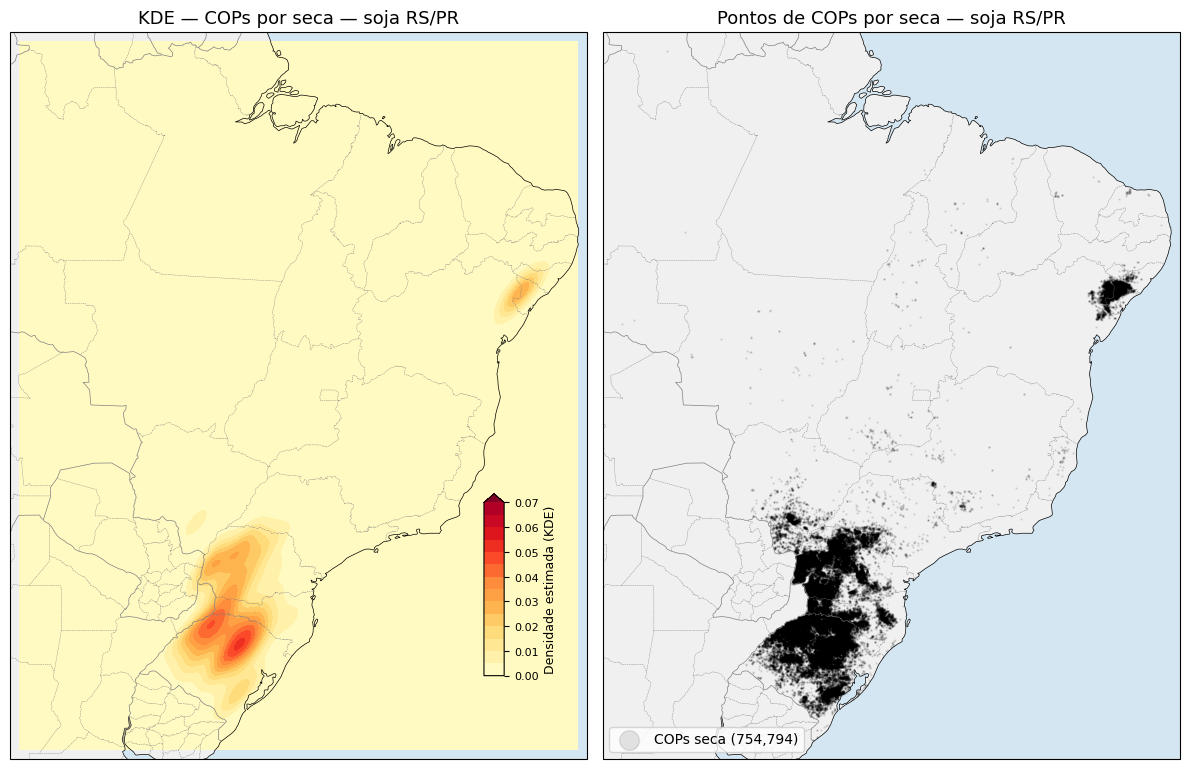

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Extent único para os dois plots
lon_all = np.concatenate([grade_lon_2d.ravel(), np.asarray(longitude_seca)])
lat_all = np.concatenate([grade_lat_2d.ravel(), np.asarray(latitude_seca)])

pad_lon = 0.5
pad_lat = 0.5

extent = [
    np.nanmin(lon_all) - pad_lon,
    np.nanmax(lon_all) + pad_lon,
    np.nanmin(lat_all) - pad_lat,
    np.nanmax(lat_all) + pad_lat,
]

# =========================
# Painel 1: KDE
# =========================

# pegando vmin e vmax dos dados, assumindo vmin 0, e montando o levels
vmin = 0
vmax = 0.075
levels = np.arange(vmin, vmax, 0.005)

contorno = ax1.contourf(
    grade_lon_2d, grade_lat_2d, densidade_2d,
    levels=levels, vmin=vmin, vmax=vmax, cmap='YlOrRd',
    extend='max',
    transform=ccrs.PlateCarree()
)

ax1.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax1.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax1.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')
ax1.set_extent(extent, crs=ccrs.PlateCarree())

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('KDE — COPs por seca — soja', fontsize=13)

# Colorbar dentro do ax1
cax = inset_axes(
    ax1,
    width="3.5%",
    height="25%",
    loc="lower right",
    borderpad=6
)

cbar = plt.colorbar(contorno, cax=cax)
cbar.set_label('Densidade estimada (KDE)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# =========================
# Painel 2: Pontos originais
# =========================
ax2.scatter(
    longitude_seca, latitude_seca,
    s=0.5, alpha=0.1, color='black',
    label=f'COPs seca ({len(longitude_seca):,})',
    transform=ccrs.PlateCarree()
)

ax2.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax2.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax2.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')
ax2.set_extent(extent, crs=ccrs.PlateCarree())

ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Pontos de COPs por seca — soja', fontsize=13)
ax2.legend(loc='lower left', markerscale=20)

plt.tight_layout()
plt.show()

> **Interpretação:** As regiões em vermelho/laranja são os "hotspots" de sinistros
> por seca. Note como a concentração não é uniforme — existem regiões claramente
> mais afetadas.
>
> **⚠️ Cuidado com a interpretação:** Alta densidade de COPs **não significa necessariamente**
> mais fraude ou mais risco real. Pode simplesmente significar que **há mais lavouras
> de soja naquela região** (e portanto mais contratos e mais COPs naturalmente).
> Para separar esses efeitos, precisaríamos normalizar pela área plantada ou pelo
> número de contratos — um refinamento que veremos em módulos seguintes.

## 2.4 Efeito do bandwidth — Vendo na prática

O bandwidth é o parâmetro mais importante do KDE. Ele controla o **nível de suavização**:
- **Bandwidth pequeno:** revela detalhes locais, mas pode criar "ruído" (picos falsos)
- **Bandwidth grande:** suaviza demais e pode esconder padrões reais

Vamos comparar três valores de bandwidth para os mesmos dados.

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


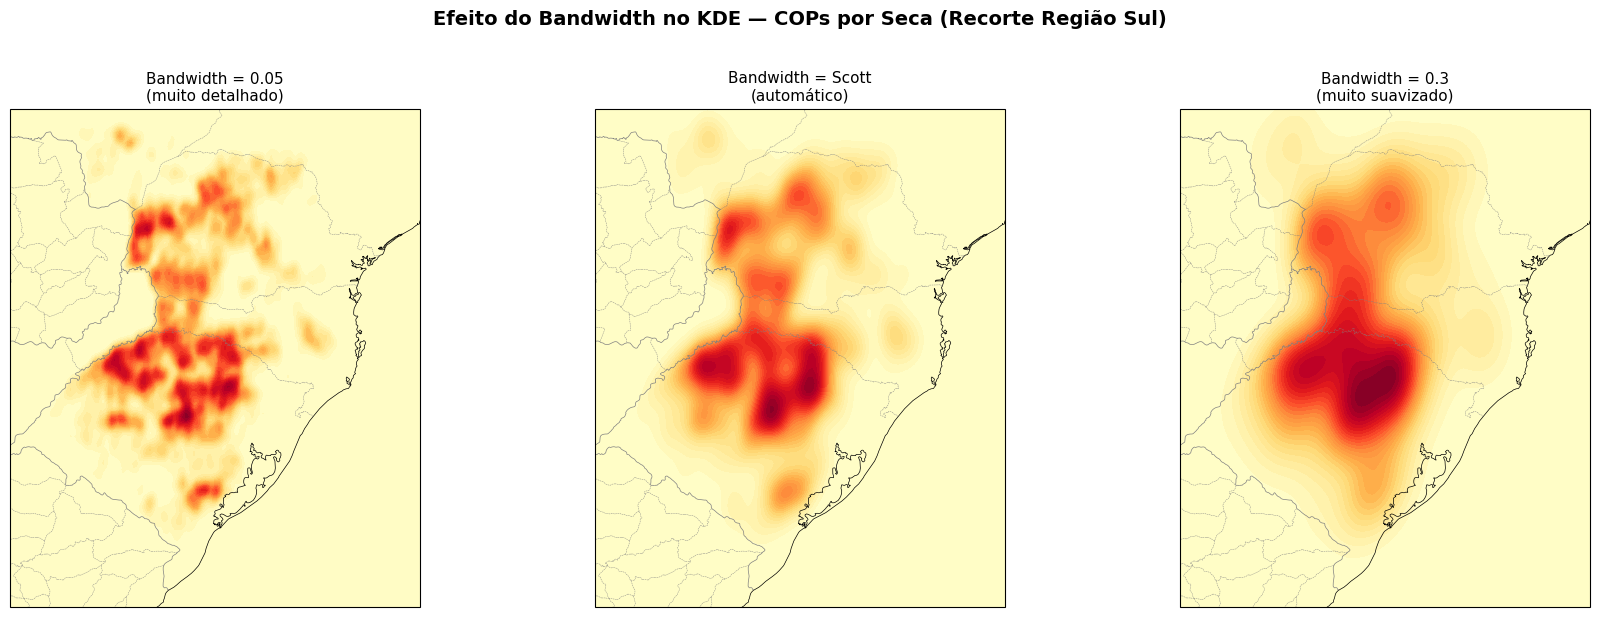

In [19]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Fazer um recorte aproximado para a Região Sul do Brasil
# (Latitudes entre -34 e -22, Longitudes entre -58 e -48)
mask_sul = (coordenadas_seca[0] >= -58.5) & (coordenadas_seca[0] <= -47.5) & \
           (coordenadas_seca[1] >= -34.0) & (coordenadas_seca[1] <= -22.0)

coords_sul = coordenadas_seca[:, mask_sul]

# Criar uma nova grade menor, focada apenas na Região Sul
lon_min, lon_max = coords_sul[0].min() - 0.5, coords_sul[0].max() + 0.5
lat_min, lat_max = coords_sul[1].min() - 0.5, coords_sul[1].max() + 0.5

g_lon = np.linspace(lon_min, lon_max, 150)
g_lat = np.linspace(lat_min, lat_max, 150)
g_lon_2d, g_lat_2d = np.meshgrid(g_lon, g_lat)
pontos_g = np.vstack([g_lon_2d.ravel(), g_lat_2d.ravel()])

# Três bandwidths para comparar
bandwidths = [0.05, 'scott', 0.3]
titulos = [
    'Bandwidth = 0.05\n(muito detalhado)',
    'Bandwidth = Scott\n(automático)',
    'Bandwidth = 0.3\n(muito suavizado)',
]

# Passar a projeção para todos os subplots na hora de criá-los
fig, eixos = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for i in range(3):
    bw = bandwidths[i]
    titulo = titulos[i]

    # Criar KDE com este bandwidth usando apenas os pontos do Sul
    kde_i = gaussian_kde(coords_sul, bw_method=bw)

    # Calcular densidade na grade reduzida
    dens_i = kde_i(pontos_g).reshape(g_lon_2d.shape)

    # Plotar no eixo correspondente (ax)
    ax = eixos[i]
    ax.contourf(g_lon_2d, g_lat_2d, dens_i, levels=30, cmap='YlOrRd')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Longitude')
    if i == 0:
        ax.set_ylabel('Latitude')

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)

    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')

fig.suptitle('Efeito do Bandwidth no KDE — COPs por Seca (Recorte Região Sul)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observe:** O mapa da esquerda (bandwidth pequeno) mostra vários "picos" locais.
> O da direita (bandwidth grande) borra tudo em uma mancha suave. O bandwidth de
> Scott (centro) é um bom compromisso automático.
>
> Na prática, a escolha depende da **pergunta**: queremos ver padrões regionais
> (bandwidth maior) ou concentrações locais (bandwidth menor)?

## 2.5 Comparando fenômenos: Seca vs Chuva excessiva

Vamos comparar a distribuição espacial de dois fenômenos opostos.
Se os padrões forem diferentes no espaço, isso reforça que os fenômenos têm
lógicas espaciais distintas — coerente com a climatologia do Sul do Brasil.

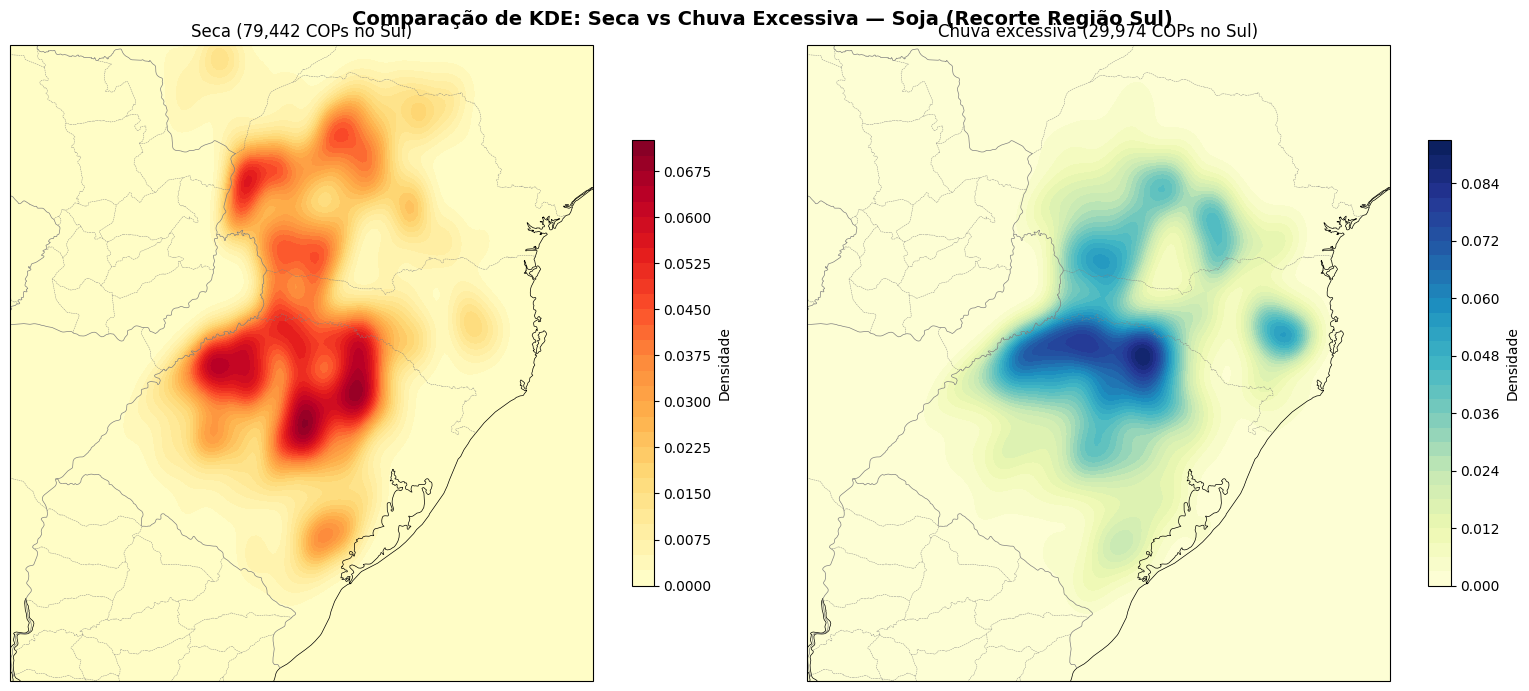

In [20]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# --- Dados de Seca ---
df_seca = df[df['nome_evento'] == 'Seca']
coords_seca = np.vstack([df_seca['longitude'].values, df_seca['latitude'].values])
# Remover possíveis NaNs
coords_seca = coords_seca[:, ~np.isnan(coords_seca).any(axis=0)]

# Máscara Sul para Seca
mask_sul_seca = (coords_seca[0] >= -58.5) & (coords_seca[0] <= -47.5) & \
                (coords_seca[1] >= -34.0) & (coords_seca[1] <= -22.0)
coords_seca_sul = coords_seca[:, mask_sul_seca]

kde_seca = gaussian_kde(coords_seca_sul, bw_method='scott')

# --- Dados de Chuva excessiva ---
df_chuva = df[df['nome_evento'] == 'Chuva excessiva']
coords_chuva = np.vstack([df_chuva['longitude'].values, df_chuva['latitude'].values])
# Remover possíveis NaNs
coords_chuva = coords_chuva[:, ~np.isnan(coords_chuva).any(axis=0)]

# Máscara Sul para Chuva excessiva
mask_sul_chuva = (coords_chuva[0] >= -58.5) & (coords_chuva[0] <= -47.5) & \
                 (coords_chuva[1] >= -34.0) & (coords_chuva[1] <= -22.0)
coords_chuva_sul = coords_chuva[:, mask_sul_chuva]

kde_chuva = gaussian_kde(coords_chuva_sul, bw_method='scott')

# --- Criar nova grade focada na Região Sul ---
lon_min, lon_max = -58.5, -47.5
lat_min, lat_max = -34.0, -22.0

g_lon = np.linspace(lon_min, lon_max, 150)
g_lat = np.linspace(lat_min, lat_max, 150)
g_lon_2d, g_lat_2d = np.meshgrid(g_lon, g_lat)
pontos_g = np.vstack([g_lon_2d.ravel(), g_lat_2d.ravel()])

# Calcular densidades na nova grade
dens_seca  = kde_seca(pontos_g).reshape(g_lon_2d.shape)
dens_chuva = kde_chuva(pontos_g).reshape(g_lon_2d.shape)

# --- Plotar lado a lado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Seca
cf1 = ax1.contourf(g_lon_2d, g_lat_2d, dens_seca, levels=30, cmap='YlOrRd')
plt.colorbar(cf1, ax=ax1, shrink=0.7, label='Densidade')
ax1.set_title(f'Seca ({coords_seca_sul.shape[1]:,} COPs no Sul)', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_xlim(lon_min, lon_max)
ax1.set_ylim(lat_min, lat_max)
ax1.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax1.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax1.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')

# Chuva excessiva
cf2 = ax2.contourf(g_lon_2d, g_lat_2d, dens_chuva, levels=30, cmap='YlGnBu')
plt.colorbar(cf2, ax=ax2, shrink=0.7, label='Densidade')
ax2.set_title(f'Chuva excessiva ({coords_chuva_sul.shape[1]:,} COPs no Sul)', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_xlim(lon_min, lon_max)
ax2.set_ylim(lat_min, lat_max)
ax2.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax2.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax2.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')

fig.suptitle('Comparação de KDE: Seca vs Chuva Excessiva — Soja (Recorte Região Sul)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretação:** Se os mapas mostrarem padrões distintos, isso sugere
> que seca e chuva excessiva afetam regiões diferentes — coerente com a
> climatologia. A seca tende a se concentrar em regiões com solos mais rasos
> e menor retenção hídrica; chuvas excessivas podem atingir áreas de relevo
> ondulado ou próximas a grandes corpos d'água.
>
> **Limitação importante:** O KDE nos mostra **onde** as COPs se concentram, mas
> **não nos diz se essa concentração é estatisticamente significativa**. Para isso,
> precisamos do **I de Moran**.

---
# Parte 3 — Preparando os Dados para o I de Moran

## 3.1 Por que mudar de pontos para áreas?

O KDE trabalha com **pontos** (as coordenadas individuais de cada COP).
Já o I de Moran trabalha com **valores associados a áreas** — no nosso caso, municípios.

A pergunta muda:  
> "Municípios com muitas COPs estão próximos de outros municípios com muitas COPs?"

Para isso, precisamos:
1. **Agregar** as COPs por município (contar quantas COPs cada município tem)
2. **Juntar** essa contagem ao shapefile de municípios (que tem os polígonos)
3. **Construir** a matriz de pesos espaciais (quem é vizinho de quem)

## 3.2 Contando COPs por município

In [21]:
import pandas as pd

# Contar o número de COPs em cada município
cops_por_municipio = (
    df
    .groupby('cd_ibge_municipio')  # Agrupar pelo código do município
    .size()                        # Contar quantas linhas em cada grupo
    .reset_index(name='total_cops')  # Transformar de volta em tabela
)

# O código do município precisa ser texto (string) para o join com shapefile
cops_por_municipio['cd_ibge_municipio'] = cops_por_municipio['cd_ibge_municipio'].astype(str)

print(f"Municípios com pelo menos 1 COP: {len(cops_por_municipio)}")
print()
print("Top 10 municípios com mais COPs:")
print(cops_por_municipio.sort_values('total_cops', ascending=False).head(10).to_string(index=False))

Municípios com pelo menos 1 COP: 1916

Top 10 municípios com mais COPs:
cd_ibge_municipio  total_cops
          4108403       15858
          4107207       15794
          4128609       15059
          4125209       14373
          4104501       11441
          4124806       10973
          4311601       10539
          4119004       10431
          4119806       10355
          4123006       10254


### Contagem também por fenômeno

Isso será útil mais adiante — vamos verificar se cada fenômeno tem um padrão
espacial diferente.

In [22]:
import pandas as pd

# Contagem por município E por fenômeno
cops_mun_evento = (
    df
    .groupby(['cd_ibge_municipio', 'nome_evento'])
    .size()
    .reset_index(name='total_cops')
)

# Pivotar: transformar em uma tabela com uma coluna para cada fenômeno
tabela_pivot = cops_mun_evento.pivot_table(
    index='cd_ibge_municipio',
    columns='nome_evento',
    values='total_cops',
    fill_value=0,     # Municípios sem aquele fenômeno recebem 0
).reset_index()

# Converter código para string
tabela_pivot['cd_ibge_municipio'] = tabela_pivot['cd_ibge_municipio'].astype(str)

print(f"Tabela com {len(tabela_pivot)} municípios")
print(f"Colunas: {list(tabela_pivot.columns)}")
tabela_pivot.head()

Tabela com 1916 municípios
Colunas: ['cd_ibge_municipio', 'Chuva excessiva', 'Chuva na colheita', 'Doença ou praga', 'Enchentes', 'Geada', 'Granizo', 'Outros fenômenos naturais fortuitos', 'Raio', 'Seca', 'Tromba de água', 'Variação excessiva de temperatura', 'Vendaval', 'Vento forte', 'Vento frio']


nome_evento,cd_ibge_municipio,Chuva excessiva,Chuva na colheita,Doença ou praga,Enchentes,Geada,Granizo,Outros fenômenos naturais fortuitos,Raio,Seca,Tromba de água,Variação excessiva de temperatura,Vendaval,Vento forte,Vento frio
0,1100320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1101492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1300144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1400050,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1400175,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3.3 Carregando o shapefile de municípios

O shapefile contém os **polígonos** (contornos) dos municípios. Precisamos dele para:
- Desenhar o mapa coroplético (pintar cada município de acordo com o valor)
- Calcular a matriz de vizinhança (quem faz fronteira com quem)

In [24]:
import geopandas as gpd

# Leitura do shapefile de municípios
# ⚠️ AJUSTE O CAMINHO se necessário
gdf_mun = gpd.read_file('BR_Municipios_2024.zip')

# Filtrar apenas RS e PR
# gdf_mun = gdf_mun[gdf_mun['SIGLA_UF'].isin(['RS', 'PR'])].copy()

# Garantir que estamos em SIRGAS 2000
gdf_mun = gdf_mun.to_crs('EPSG:4674')

# Padronizar o código do município para string
gdf_mun['CD_MUN'] = gdf_mun['CD_MUN'].astype(str)

print(f"Municípios no shapefile: {len(gdf_mun)}")
gdf_mun[['CD_MUN', 'NM_MUN', 'SIGLA_UF']].head()

Municípios no shapefile: 5573


,CD_MUN,NM_MUN,SIGLA_UF
0,2504108,Carrapateira,PB
1,1718451,Pugmil,TO
2,2104206,Fortuna,MA
3,5219902,São Francisco de Goiás,GO
4,2708600,São Miguel dos Campos,AL


## 3.4 Juntar contagem de COPs ao shapefile

Vamos "colar" a contagem de COPs nos polígonos dos municípios. Municípios que
não tiveram nenhuma COP receberão valor 0.

In [25]:
import geopandas as gpd

# Juntar contagem total de COPs ao shapefile
gdf_analise = gdf_mun.merge(
    cops_por_municipio,
    left_on='CD_MUN',
    right_on='cd_ibge_municipio',
    how='left',   # Manter TODOS os municípios, mesmo sem COP
)

# Municípios sem COP ficam com NaN — vamos preencher com 0
gdf_analise['total_cops'] = gdf_analise['total_cops'].fillna(0).astype(int)

print(f"Total de municípios: {len(gdf_analise)}")
print(f"  Com COPs: {(gdf_analise['total_cops'] > 0).sum()}")
print(f"  Sem COPs: {(gdf_analise['total_cops'] == 0).sum()}")

Total de municípios: 5573
  Com COPs: 1916
  Sem COPs: 3657


In [26]:
import geopandas as gpd

# Juntar também a tabela pivotada (COPs por fenômeno)
gdf_analise = gdf_analise.merge(
    tabela_pivot,
    on='cd_ibge_municipio',
    how='left',
)

# Preencher NaN com 0 nas colunas de fenômenos
colunas_fenomeno = [c for c in tabela_pivot.columns if c != 'cd_ibge_municipio']
for col in colunas_fenomeno:
    if col in gdf_analise.columns:
        gdf_analise[col] = gdf_analise[col].fillna(0).astype(int)

print("Colunas disponíveis:")
print([c for c in gdf_analise.columns if c not in ['geometry', 'cd_ibge_municipio']])

Colunas disponíveis:
['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'total_cops', 'Chuva excessiva', 'Chuva na colheita', 'Doença ou praga', 'Enchentes', 'Geada', 'Granizo', 'Outros fenômenos naturais fortuitos', 'Raio', 'Seca', 'Tromba de água', 'Variação excessiva de temperatura', 'Vendaval', 'Vento forte', 'Vento frio']


### Mapa coroplético: COPs por município

Um **mapa coroplético** pinta cada município de acordo com um valor numérico.
Vamos pintar conforme o número total de COPs.

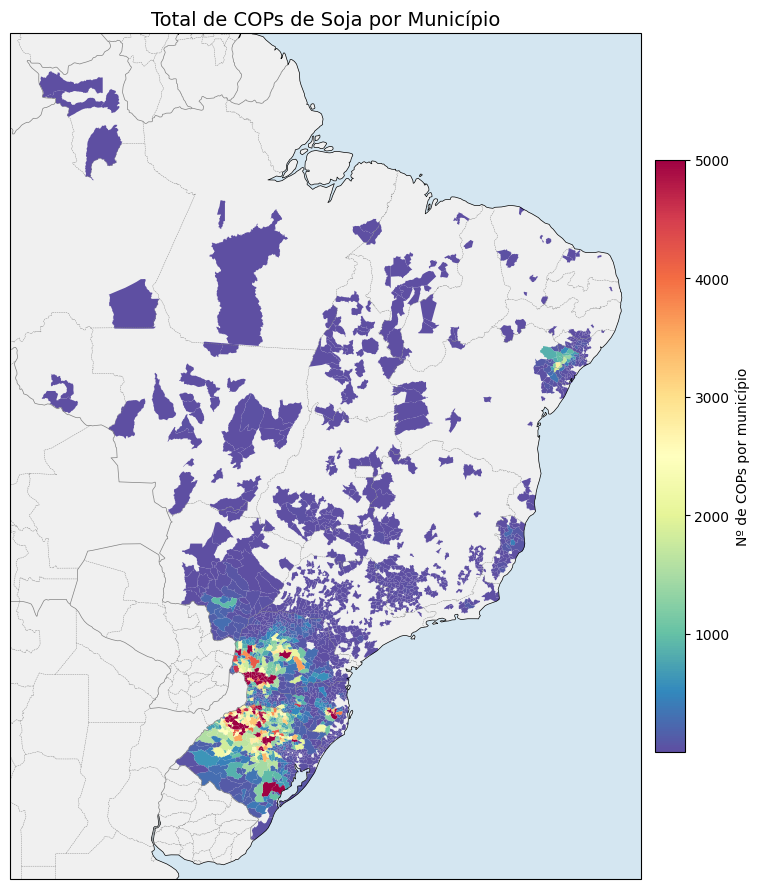

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 9), subplot_kw={'projection': ccrs.PlateCarree()})

gdf_analise[gdf_analise['total_cops'] > 0 ].plot(
    column='total_cops',       # Coluna que define a cor
    cmap='Spectral_r',             # Esquema de cores
    vmin=1,
    vmax=5000,
    legend=True,
    legend_kwds={
        'label': 'Nº de COPs por município',
        'shrink': 0.7,
        'pad':0.01
    },
    ax=ax,
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(states, linewidth=0.3, edgecolor='gray', linestyle='--')

ax.set_title('Total de COPs de Soja por Município', fontsize=14)

plt.tight_layout()
plt.show()

> **Compare** este mapa com o KDE anterior. Ambos mostram onde as COPs se concentram,
> mas de formas diferentes:
> - O **KDE** mostra a intensidade "livre", sem fronteiras administrativas
> - O **mapa coroplético** agrega por município — útil para gestão e tomada de decisão
>
> Cada abordagem tem vantagens. Essa diferença entre "como agregamos os dados"
> e "que padrão aparece" está no coração de um problema que vamos discutir no
> Bloco 2: o **MAUP** (Problema da Unidade de Área Modificável).

---
# Parte 4 — I de Moran Global: Existe Padrão Espacial?

## 4.1 A pergunta central

Olhando o mapa coroplético, **parece** que municípios com muitas COPs estão próximos
de outros municípios com muitas COPs. Mas será que isso é real ou é apenas impressão visual?

O **I de Moran Global** é um teste estatístico que responde exatamente essa pergunta:

> **"Os valores que observamos (neste caso, número de COPs) estão organizados
> espacialmente de forma não aleatória?"**

O resultado é um número entre -1 e +1:

| Valor do I | Significado |
|-----------|-------------|
| **I ≈ +1** | Autocorrelação positiva forte — vizinhos são parecidos |
| **I ≈ 0** | Sem padrão espacial — distribuição aleatória |
| **I ≈ -1** | Autocorrelação negativa — vizinhos são opostos (raro) |

## 4.2 A Lei de Tobler — Fundamento conceitual

O I de Moran se apoia numa ideia fundamental da geografia, a **Primeira Lei da
Geografia de Tobler (1970)**:

> *"Tudo está relacionado com tudo, mas coisas próximas estão mais relacionadas
> do que coisas distantes."*

No nosso contexto: se uma gleba no município A sofreu seca, é provável que glebas
em municípios vizinhos também tenham sofrido — porque **o clima não respeita
fronteiras municipais**. Um evento de estiagem prolongada cobre regiões inteiras,
não se limita a um único município.

O I de Moran **formaliza** essa intuição como número e **testa** se é estatisticamente
significativo.

## 4.3 A matriz de pesos espaciais — Quem é vizinho de quem?

Para calcular o I de Moran, precisamos de uma **matriz de pesos espaciais (W)**.
Essa matriz define a estrutura de vizinhança: para cada município, quem são seus vizinhos?

Vamos usar o critério **Queen** (Rainha, como no xadrez): dois municípios são vizinhos
se compartilham qualquer parte da fronteira — até mesmo um único ponto de contato.

In [28]:
# Importar a ferramenta de pesos espaciais do PySAL
from libpysal.weights import Queen

# Construir a matriz de vizinhança Queen
pesos = Queen.from_dataframe(gdf_analise, use_index=False)

print(f"Matriz de pesos criada!")
print(f"  Número de municípios: {pesos.n}")
print(f"  Número médio de vizinhos por município: {pesos.mean_neighbors:.1f}")
print(f"  Mínimo de vizinhos: {pesos.min_neighbors}")
print(f"  Máximo de vizinhos: {pesos.max_neighbors}")

Matriz de pesos criada!
  Número de municípios: 5573
  Número médio de vizinhos por município: 5.9
  Mínimo de vizinhos: 0
  Máximo de vizinhos: 23


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 3909, 4656.
  W.__init__(self, neighbors, ids=ids, **kw)


### Entendendo a vizinhança de um município específico

Vamos olhar os vizinhos de um município para entender o que a matriz contém.

In [29]:
# Vamos ver os vizinhos do município com mais COPs

# Descobrir qual é o município com maior total_cops
idx_mais_cops = gdf_analise['total_cops'].idxmax()
nome_mun = gdf_analise.loc[idx_mais_cops, 'NM_MUN']
uf_mun   = gdf_analise.loc[idx_mais_cops, 'SIGLA_UF']
n_viz    = len(pesos.neighbors[idx_mais_cops])
cops_mun = gdf_analise.loc[idx_mais_cops, 'total_cops']

print(f"Município com mais COPs: {nome_mun}/{uf_mun}")
print(f"  Total de COPs neste município: {cops_mun}")
print(f"  Número de vizinhos: {n_viz}")
print()

# Mostrar os nomes e COPs dos vizinhos
print(f"Vizinhos de {nome_mun}:")
for idx_v in pesos.neighbors[idx_mais_cops]:
    nome_v = gdf_analise.loc[idx_v, 'NM_MUN']
    cops_v = gdf_analise.loc[idx_v, 'total_cops']
    print(f"  → {nome_v}: {cops_v} COPs")

Município com mais COPs: Francisco Beltrão/PR
  Total de COPs neste município: 15858
  Número de vizinhos: 10

Vizinhos de Francisco Beltrão:
  → Marmeleiro: 3007 COPs
  → Itapejara d'Oeste: 6216 COPs
  → Verê: 15059 COPs
  → Manfrinópolis: 950 COPs
  → Renascença: 3061 COPs
  → Flor da Serra do Sul: 1543 COPs
  → Nova Esperança do Sudoeste: 5187 COPs
  → Enéas Marques: 4258 COPs
  → Bom Sucesso do Sul: 3696 COPs
  → Ampére: 3329 COPs


### Visualizando a vizinhança no mapa

Vamos colorir o município e seus vizinhos para ver a relação de contiguidade.

/tmp/ipykernel_37567/2695964573.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroide = mun_central.geometry.centroid.iloc[0]


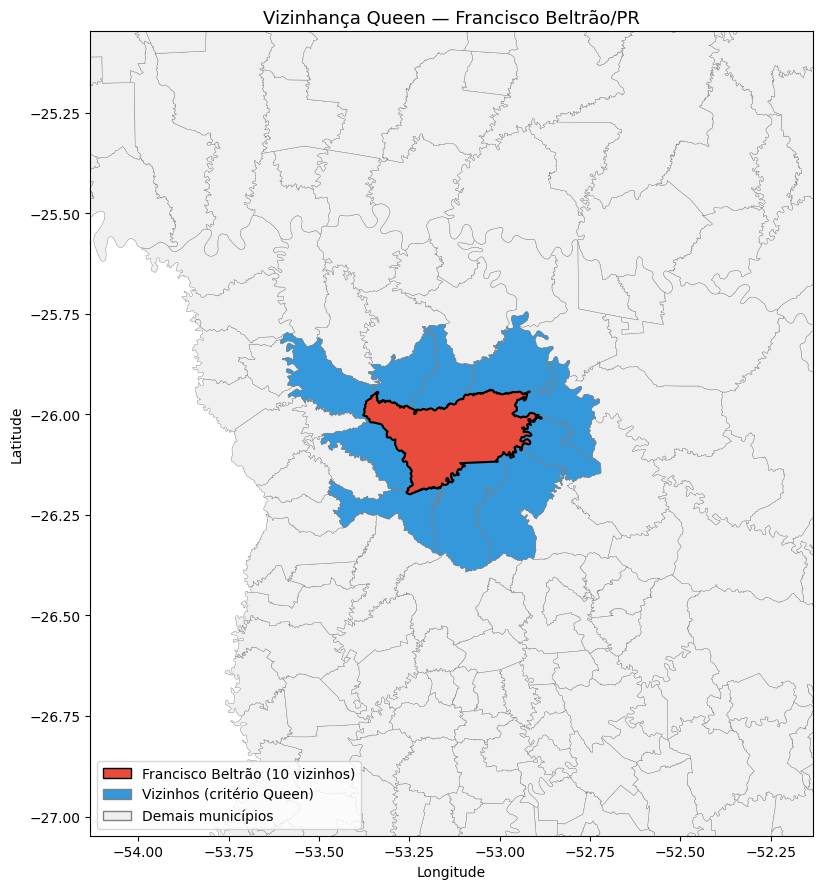

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 9))

# Todos os municípios em cinza claro (fundo)
gdf_analise.plot(ax=ax, color='#f0f0f0', edgecolor='gray', linewidth=0.3)

# Vizinhos em azul
vizinhos_idx = pesos.neighbors[idx_mais_cops]
gdf_analise.iloc[vizinhos_idx].plot(ax=ax, color='#3498DB', edgecolor='gray', linewidth=0.5)

# Município central em vermelho
mun_central = gdf_analise.iloc[[idx_mais_cops]]
mun_central.plot(ax=ax, color='#E74C3C', edgecolor='black', linewidth=1.5)

# Calcular o centroide para definir o zoom (extent de ±1°)
centroide = mun_central.geometry.centroid.iloc[0]
ax.set_xlim(centroide.x - 1, centroide.x + 1)
ax.set_ylim(centroide.y - 1, centroide.y + 1)

ax.legend(
    handles=[
        Patch(facecolor='#E74C3C', edgecolor='black', label=f'{nome_mun} ({n_viz} vizinhos)'),
        Patch(facecolor='#3498DB', edgecolor='gray', label='Vizinhos (critério Queen)'),
        Patch(facecolor='#f0f0f0', edgecolor='gray', label='Demais municípios'),
    ],
    loc='lower left',
    fontsize=10,
)
ax.set_title(f'Vizinhança Queen — {nome_mun}/{uf_mun}', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 4.4 Calculando o I de Moran Global

Agora sim! Com a matriz de pesos pronta, calcular o I de Moran é simples:
basta passar os **valores** (total de COPs) e os **pesos** (vizinhança).

O PySAL cuida de toda a matemática, incluindo o **teste de significância**:
ele embaralha os valores entre os municípios 999 vezes (permutações de Monte Carlo)
e verifica se o I observado é diferente do que surgiria por acaso.

In [31]:
# Aqui vamos usar a vizinhança do tipo Queen.
# Ela considera como vizinhos os municípios que encostam por lado ou vértice.
w = Queen.from_dataframe(gdf_analise)

/tmp/ipykernel_37567/928739458.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_analise)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 3909, 4656.
  W.__init__(self, neighbors, ids=ids, **kw)


In [32]:
# Island é um município que ficou sem vizinhos na matriz de pesos.
print("Islands:", w.islands)


Islands: [3909, 4656]


In [33]:
# Remover os islands antes de calcular o Moran
gdf_sem_islands = gdf_analise.drop(index=w.islands).copy()
gdf_sem_islands = gdf_sem_islands.reset_index(drop=True)

In [34]:
# Agora recriamos a matriz de pesos
w = Queen.from_dataframe(gdf_sem_islands)
w.transform = "r"

/tmp/ipykernel_37567/4061940811.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_sem_islands)


In [35]:
gdf_sem_islands

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,...,Geada,Granizo,Outros fenômenos naturais fortuitos,Raio,Seca,Tromba de água,Variação excessiva de temperatura,Vendaval,Vento forte,Vento frio
0,2504108,Carrapateira,250015,Cajazeiras,2504,Sousa - Cajazeiras,25,Paraíba,PB,2,...,0,0,0,0,0,0,0,0,0,0
1,1718451,Pugmil,170003,Paraíso do Tocantins,1701,Palmas,17,Tocantins,TO,1,...,0,0,0,0,0,0,0,0,0,0
2,2104206,Fortuna,210016,Presidente Dutra,2104,Presidente Dutra,21,Maranhão,MA,2,...,0,0,0,0,0,0,0,0,0,0
3,5219902,São Francisco de Goiás,520002,Anápolis,5201,Goiânia,52,Goiás,GO,5,...,0,0,0,0,0,0,0,0,0,0
4,2708600,São Miguel dos Campos,270004,São Miguel dos Campos,2701,Maceió,27,Alagoas,AL,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5566,2928307,Santanópolis,290029,Feira de Santana,2910,Feira de Santana,29,Bahia,BA,2,...,0,0,0,0,0,0,0,0,0,0
5567,1505635,Piçarra,150009,Marabá,1503,Marabá,15,Pará,PA,1,...,0,0,0,0,0,0,0,0,0,0
5568,2904308,Brejões,290003,Santo Antônio de Jesus,2902,Santo Antônio de Jesus,29,Bahia,BA,2,...,0,0,0,0,0,0,0,0,0,0
5569,1713205,Miracema do Tocantins,170004,Miracema do Tocantins,1701,Palmas,17,Tocantins,TO,1,...,0,0,0,0,0,0,0,0,0,0


In [36]:
from esda.moran import Moran

# Valores: total de COPs por município
valores = gdf_sem_islands['total_cops'].values

# Calcular o I de Moran Global com 999 permutações de Monte Carlo
moran_global = Moran(valores, w, permutations=999)

print("=" * 55)
print("  RESULTADO — I de Moran Global (total de COPs)")
print("=" * 55)
print(f"  I de Moran observado:        {moran_global.I:.4f}")
print(f"  Valor esperado (aleatório):  {moran_global.EI:.4f}")
print(f"  p-valor (Monte Carlo):       {moran_global.p_sim:.4f}")
print(f"  z-score:                     {moran_global.z_sim:.4f}")
print("=" * 55)

  RESULTADO — I de Moran Global (total de COPs)
  I de Moran observado:        0.7284
  Valor esperado (aleatório):  -0.0002
  p-valor (Monte Carlo):       0.0010
  z-score:                     93.0889


### Interpretando o resultado

Vamos traduzir os números acima em palavras.

In [37]:
# Interpretação do p-valor
if moran_global.p_sim < 0.01:
    sig = "altamente significativo (p < 0.01)"
elif moran_global.p_sim < 0.05:
    sig = "significativo (p < 0.05)"
else:
    sig = "NÃO significativo (p ≥ 0.05)"

# Interpretação da direção
if moran_global.I > 0:
    direcao = "POSITIVA — municípios vizinhos tendem a ter valores semelhantes"
elif moran_global.I < 0:
    direcao = "NEGATIVA — municípios vizinhos tendem a ter valores opostos"
else:
    direcao = "NULA — sem padrão detectável"

print(f"Autocorrelação espacial: {direcao}")
print(f"Significância estatística: {sig}")
print()
print("Em termos práticos:")
print(f"  O I = {moran_global.I:.4f} indica que municípios com muitas COPs")
print(f"  estão próximos de outros municípios com muitas COPs.")
print(f"  O p-valor = {moran_global.p_sim:.4f} indica que este padrão")
if moran_global.p_sim < 0.05:
    print(f"  é estatisticamente significativo — NÃO é fruto do acaso.")
else:
    print(f"  pode ser explicado pelo acaso.")

Autocorrelação espacial: POSITIVA — municípios vizinhos tendem a ter valores semelhantes
Significância estatística: altamente significativo (p < 0.01)

Em termos práticos:
  O I = 0.7284 indica que municípios com muitas COPs
  estão próximos de outros municípios com muitas COPs.
  O p-valor = 0.0010 indica que este padrão
  é estatisticamente significativo — NÃO é fruto do acaso.


### Inset com a posição do I observado
Como o valor observado pode ficar muito longe da distribuição, colocamos um inset mostrando isso.

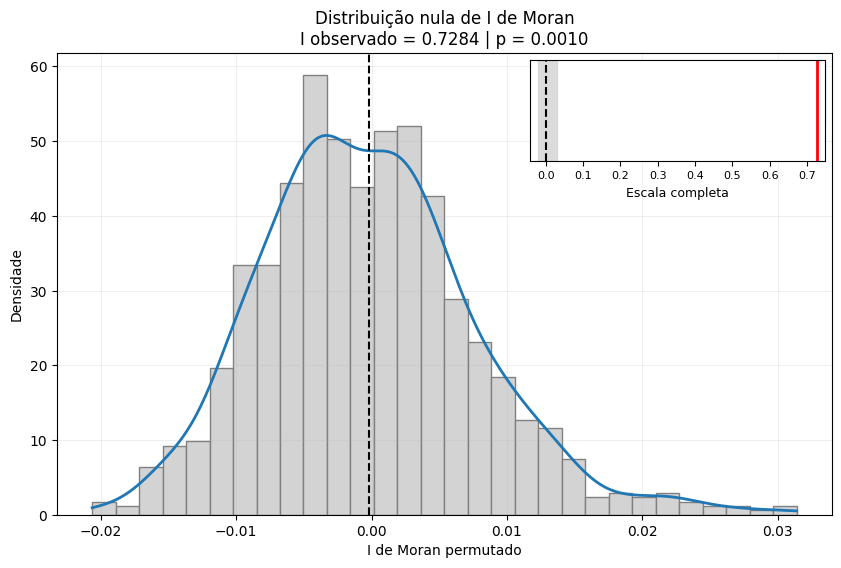

In [38]:
sim = moran_global.sim
I_obs = moran_global.I
EI = moran_global.EI

x = np.linspace(sim.min(), sim.max(), 500)
kde = gaussian_kde(sim)
y_kde = kde(x)

fig, ax = plt.subplots(figsize=(10, 6))

# Histograma
ax.hist(
    sim,
    bins=30,
    density=True,
    color="lightgray",
    edgecolor="gray",
    label="Permutações"
)

# KDE
ax.plot(x, y_kde, linewidth=2, label="KDE")

# Linha do valor esperado
ax.axvline(
    EI,
    color="black",
    linestyle="--",
    label=f"Valor esperado = {EI:.4f}"
)

ax.set_title(
    f"Distribuição nula de I de Moran\n"
    f"I observado = {I_obs:.4f} | p = {moran_global.p_sim:.4f}"
)
ax.set_xlabel("I de Moran permutado")
ax.set_ylabel("Densidade")
ax.legend()
ax.grid(alpha=0.2)

# Inset
ax_inset = inset_axes(ax, width="38%", height="22%", loc="upper right")

ax_inset.axvspan(sim.min(), sim.max(), color="lightgray", alpha=0.8)
ax_inset.axvline(EI, color="black", linestyle="--")
ax_inset.axvline(I_obs, color="red", linewidth=2)

ax_inset.set_xlim(min(sim.min(), I_obs) - 0.02, max(sim.max(), I_obs) + 0.02)
ax_inset.set_yticks([])
ax_inset.set_xlabel("Escala completa", fontsize=9)
ax_inset.tick_params(axis="x", labelsize=8)

plt.show()

O histograma representa os valores de I de Moran obtidos nas permutações aleatórias.
Esses valores formam a chamada **distribuição nula**, ou seja, o comportamento esperado se não existisse organização espacial.

A linha tracejada mostra o **valor esperado**, que costuma ficar perto de zero.

O valor de Moran observado nos dados reais foi muito maior do que os valores das permutações.
Por isso, ele aparece separado no inset, à direita.

Isso indica que o padrão espacial observado **não é aleatório**.
Municípios com valores altos tendem a ficar próximos de outros municípios com valores altos, e o mesmo vale para valores baixos.

O p-valor pequeno reforça que esse resultado é estatisticamente significativo.

Em termos substantivos, esse histograma diz que:

**os municípios com muitas COPs tendem a estar perto de municípios também com muitas COPs, e os com poucas COPs tendem a estar perto de outros com poucas COPs.**

Ou seja, há **autocorrelação espacial positiva muito intensa**.

> O histograma das permutações mostra que, sob a hipótese nula de aleatoriedade espacial, os valores simulados do I de Moran ficaram concentrados em torno de zero, entre aproximadamente -0.02 e 0.03. O valor observado (I = 0.7286) ficou muito acima dessa faixa, indicando que o padrão espacial dos registros está muito distante do acaso. O p-valor de 0.0010 confirma significância estatística, evidenciando forte autocorrelação espacial positiva no total de COPs entre os municípios.



## 4.5 Diagrama de Espalhamento de Moran

O I de Moran pode ser visualizado como um gráfico de dispersão:
- **Eixo X:** valor do município (padronizado — subtraído da média e dividido pelo desvio padrão)
- **Eixo Y:** média dos valores dos vizinhos (padronizada)

Os quatro quadrantes do gráfico representam:

| Quadrante | Significado | Exemplo |
|-----------|-------------|---------|
| **Alto-Alto** (↗) | Município com muitas COPs, vizinhos com muitas | Cluster de alta incidência |
| **Baixo-Baixo** (↙) | Município com poucas COPs, vizinhos com poucas | Cluster de baixa incidência |
| **Alto-Baixo** (↘) | Muitas COPs, mas vizinhos com poucas | Outlier espacial |
| **Baixo-Alto** (↖) | Poucas COPs, mas vizinhos com muitas | Outlier espacial |

A **inclinação da reta** que passa pelos pontos é exatamente o valor do I de Moran.
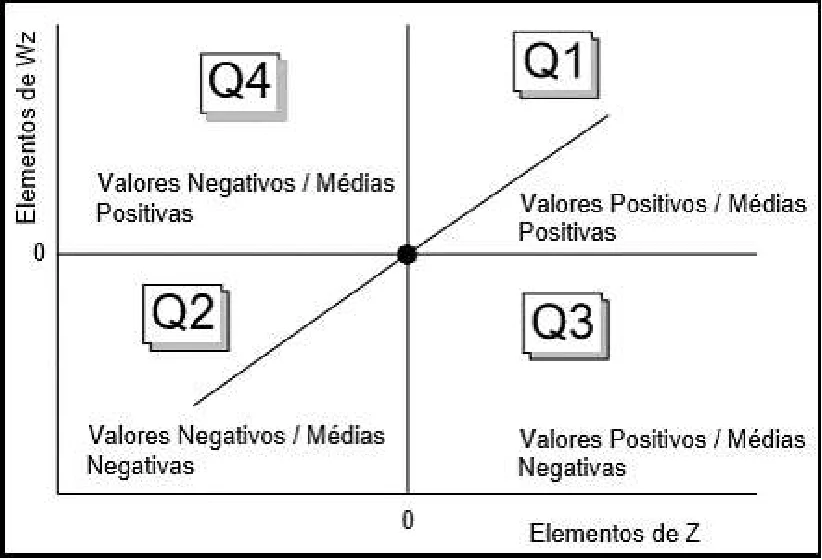
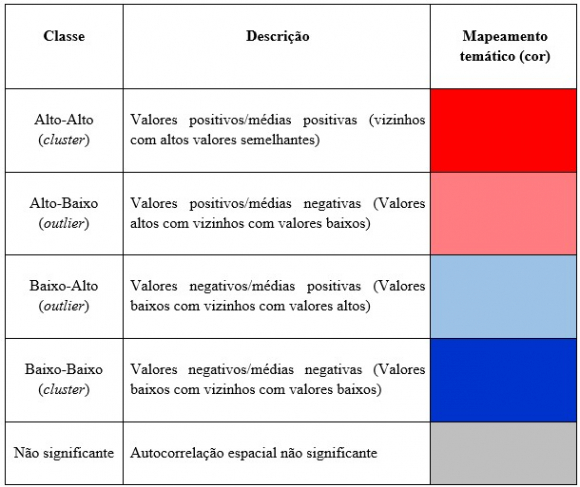

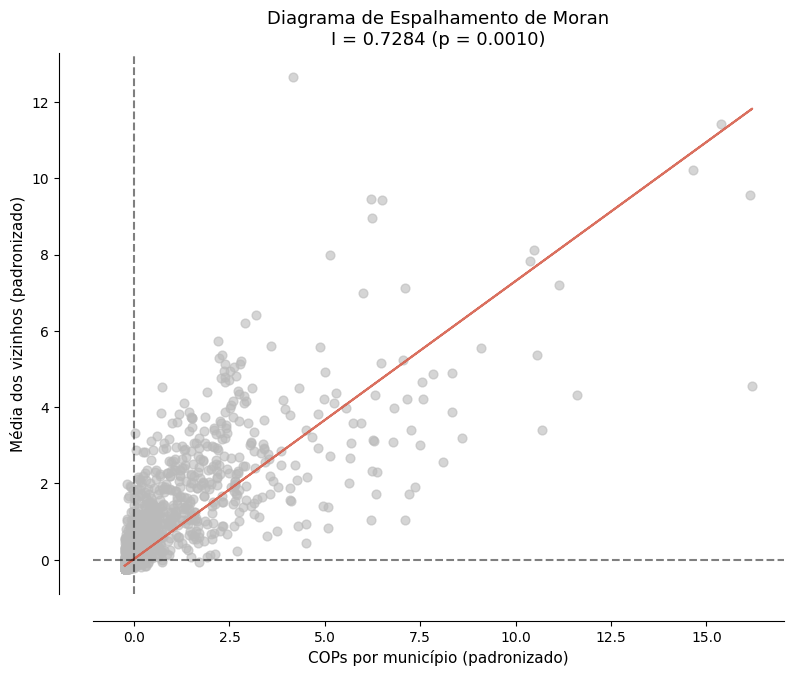

In [43]:
from splot.esda import moran_scatterplot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# O splot gera o diagrama de espalhamento completo
moran_scatterplot(moran_global, ax=ax, aspect_equal=True)

ax.set_title(
    f'Diagrama de Espalhamento de Moran\n'
    f'I = {moran_global.I:.4f} (p = {moran_global.p_sim:.4f})',
    fontsize=13
)
ax.set_xlabel('COPs por município (padronizado)', fontsize=11)
ax.set_ylabel('Média dos vizinhos (padronizado)', fontsize=11)

plt.tight_layout()
plt.show()

> **Como ler:** Cada ponto é um município. Se a maioria dos pontos está nos
> quadrantes Alto-Alto e Baixo-Baixo, existe autocorrelação positiva
> (o I de Moran é positivo). A reta de regressão mostra a tendência geral.

## 4.7 Moran por fenômeno adverso

Uma extensão natural: verificar se cada fenômeno tem seu próprio padrão espacial.
Seca e Chuva excessiva, por exemplo, devem ter distribuições espaciais bem diferentes.

In [41]:
from esda.moran import Moran

# Lista de fenômenos para testar
fenomenos = ['Seca', 'Chuva excessiva', 'Granizo', 'Geada']

print("=" * 65)
print(f"  {'Fenômeno':<25} {'I Moran':>10} {'p-valor':>10} {'Significativo?':>15}")
print("=" * 65)

for fenomeno in fenomenos:
    if fenomeno in gdf_analise.columns:
        valores_f = gdf_analise[fenomeno].values
        moran_f = Moran(valores_f, pesos, permutations=999)

        if moran_f.p_sim < 0.01:
            sig = "Sim ***"
        elif moran_f.p_sim < 0.05:
            sig = "Sim *"
        else:
            sig = "Não"

        print(f"  {fenomeno:<25} {moran_f.I:>10.4f} {moran_f.p_sim:>10.4f} {sig:>15}")

print("=" * 65)
print()
print("Legenda: *** = p < 0.01 | * = p < 0.05")

  Fenômeno                     I Moran    p-valor  Significativo?
('WARNING: ', 3909, ' is an island (no neighbors)')
('WARNING: ', 4656, ' is an island (no neighbors)')
  Seca                          0.7097     0.0010         Sim ***
  Chuva excessiva               0.7474     0.0010         Sim ***
  Granizo                       0.4694     0.0010         Sim ***
  Geada                         0.6221     0.0010         Sim ***

Legenda: *** = p < 0.01 | * = p < 0.05


> **Reflexão:** Compare os valores de I de Moran entre os fenômenos.
> Provavelmente a Seca terá o maior I (padrão espacial forte, pois a estiagem
> cobre regiões extensas), enquanto o Granizo terá um I menor (fenômeno mais
> localizado, com menos padrão espacial de larga escala).

---
# 📝 Resumo do Bloco 1

| Técnica | O que faz | Entrada | Saída |
|---------|----------|---------|-------|
| **KDE** | Estima densidade contínua a partir de pontos | Coordenadas (lon, lat) das COPs | Superfície de calor (mapa) |
| **I de Moran** | Testa se existe autocorrelação espacial | Valores por município + vizinhança | Estatística I, p-valor, diagrama |

### Conceitos-chave deste bloco:

- **KDE** transforma pontos em superfície contínua; o **bandwidth** controla a suavização
- **Lei de Tobler:** coisas próximas são mais parecidas que coisas distantes
- **Matriz de pesos (W):** define quem é vizinho de quem (usamos critério Queen)
- **I de Moran:** mede autocorrelação espacial global; testado via Monte Carlo
- **Diagrama de Moran:** quadrantes Alto-Alto, Baixo-Baixo, Alto-Baixo, Baixo-Alto

### O que vem no Bloco 2:
- **LISA:** abre o I de Moran e identifica **quais municípios** formam clusters
- **MAUP:** mostra como mudar a unidade de agregação altera os resultados
- **Getis-Ord Gi*:** identifica hotspots e coldspots estatisticamente significativos

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 3909, 4656.
  W.__init__(self, neighbors, ids=ids, **kw)


Islands: [3909, 4656]


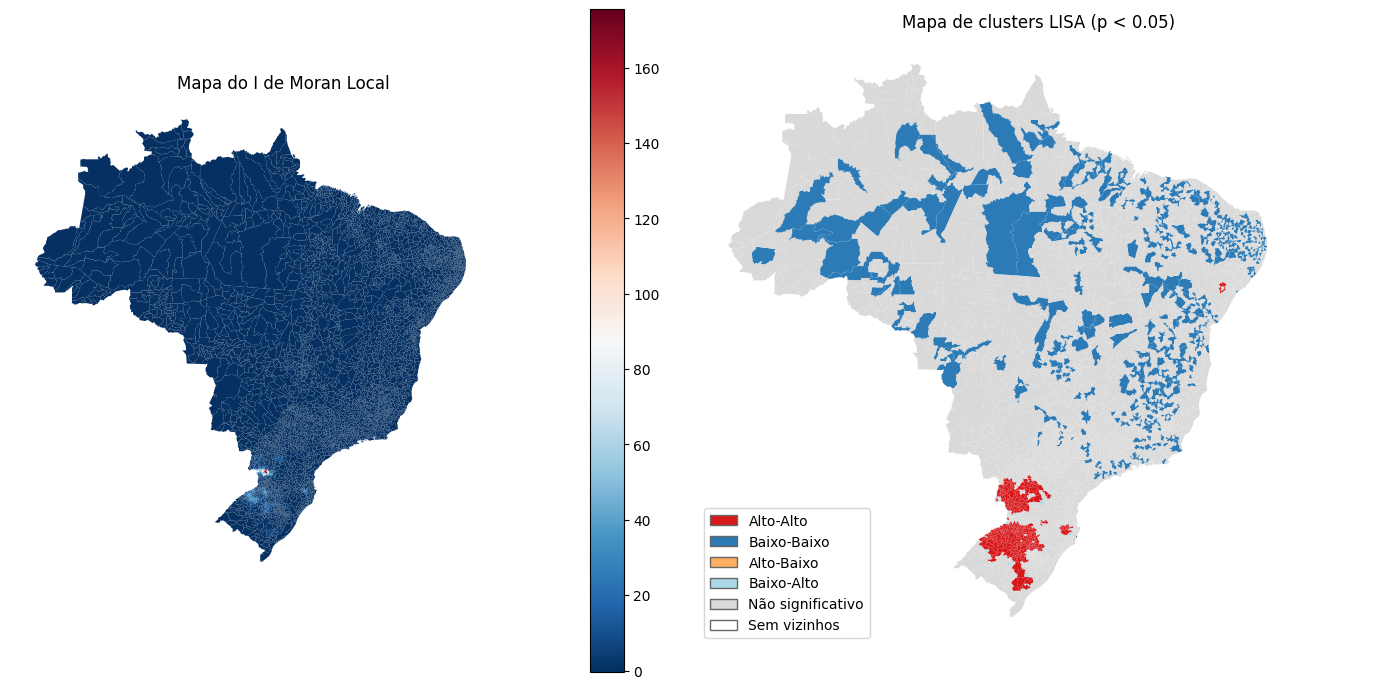

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran_Local

# --------------------------------------------------
# 1) Preparar os dados
# --------------------------------------------------
col_valor = "total_cops"   # troque pelo nome da sua coluna
col_nome = "NM_MUN"        # troque se o nome da coluna for outro

gdf_plot = gdf_analise[[col_nome, col_valor, "geometry"]].copy()

# matriz de vizinhança inicial
w0 = Queen.from_dataframe(gdf_plot, use_index=True)
islands = w0.islands

print("Islands:", islands)

# --------------------------------------------------
# 2) Remover islands para calcular o Moran Local
# --------------------------------------------------
gdf_validos = gdf_plot.drop(index=islands).copy()

w = Queen.from_dataframe(gdf_validos, use_index=True)
w.transform = "r"

y = gdf_validos[col_valor].values
moran_local = Moran_Local(y, w, permutations=999)

# --------------------------------------------------
# 3) Guardar os resultados no GeoDataFrame original
# --------------------------------------------------
gdf_plot["I_local"] = np.nan
gdf_plot["p_local"] = np.nan
gdf_plot["q"] = np.nan
gdf_plot["cluster"] = "Sem vizinhos"

gdf_plot.loc[gdf_validos.index, "I_local"] = moran_local.Is
gdf_plot.loc[gdf_validos.index, "p_local"] = moran_local.p_sim
gdf_plot.loc[gdf_validos.index, "q"] = moran_local.q

sig = gdf_plot["p_local"] < 0.05

gdf_plot.loc[gdf_validos.index, "cluster"] = "Não significativo"
gdf_plot.loc[sig & (gdf_plot["q"] == 1), "cluster"] = "Alto-Alto"
gdf_plot.loc[sig & (gdf_plot["q"] == 2), "cluster"] = "Baixo-Alto"
gdf_plot.loc[sig & (gdf_plot["q"] == 3), "cluster"] = "Baixo-Baixo"
gdf_plot.loc[sig & (gdf_plot["q"] == 4), "cluster"] = "Alto-Baixo"

# --------------------------------------------------
# 4) Plotar os mapas
# --------------------------------------------------
cores_cluster = {
    "Alto-Alto": "#d7191c",
    "Baixo-Baixo": "#2c7bb6",
    "Alto-Baixo": "#fdae61",
    "Baixo-Alto": "#abd9e9",
    "Não significativo": "#d9d9d9",
    "Sem vizinhos": "#ffffff"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Mapa 1: valor do I local
gdf_plot.plot(
    column="I_local",
    cmap="RdBu_r",
    legend=True,
    ax=axes[0],
    missing_kwds={"color": "white", "label": "Sem vizinhos"}
)
axes[0].set_title("Mapa do I de Moran Local")
axes[0].axis("off")

# Mapa 2: clusters LISA
gdf_plot.plot(
    color=gdf_plot["cluster"].map(cores_cluster),
    ax=axes[1],
)
axes[1].set_title("Mapa de clusters LISA (p < 0.05)")
axes[1].axis("off")

legenda = [
    Patch(facecolor=cores_cluster["Alto-Alto"], edgecolor="0.4", label="Alto-Alto"),
    Patch(facecolor=cores_cluster["Baixo-Baixo"], edgecolor="0.4", label="Baixo-Baixo"),
    Patch(facecolor=cores_cluster["Alto-Baixo"], edgecolor="0.4", label="Alto-Baixo"),
    Patch(facecolor=cores_cluster["Baixo-Alto"], edgecolor="0.4", label="Baixo-Alto"),
    Patch(facecolor=cores_cluster["Não significativo"], edgecolor="0.4", label="Não significativo"),
    Patch(facecolor=cores_cluster["Sem vizinhos"], edgecolor="0.4", label="Sem vizinhos")
]
axes[1].legend(handles=legenda, loc="lower left", frameon=True)

plt.tight_layout()
plt.show()